In [1]:
import sympy as sym
from sympy.printing.dot import dotprint
import graphviz

In [2]:
def sympy_expr_to_graph(expr):
    """
    Convert a SymPy expression into a Graphviz Digraph for visualization.
    """
    dot = graphviz.Digraph(comment="SymPy Expression Tree")
    visited = {}

    def add_node(e):
        # Use id(e) to uniquely identify nodes
        node_id = str(id(e))
        if node_id not in visited:
            visited[node_id] = True
            # Label: operator or symbol/number
            etype = type(e)
            etype_name = str(etype).split('.')[-1].split("'")[0]  #strip off only the fundamental not the whole class hierarchy
            label = str(e)
            new_label = etype_name+'\n'+label
            #print(new_label)
            dot.node(node_id, new_label)

            # Recursively add children
            if hasattr(e, 'args'):
                for arg in e.args:
                    child_id = add_node(arg)
                    dot.edge(node_id, child_id)
        return node_id

    add_node(expr)
    return dot


def graph_expr(expr):
    dot_form = dotprint(expr)
    return graphviz.Source(dot_form)

In [3]:
from sympy.abc import x, y, z
a,b,c,d,e,f = sym.symbols('a:f')
t  = sym.Symbol('t')
n  = sym.Symbol('n')
mu = sym.Symbol('mu')
g  = sym.Function('g')
setg = sympy_expr_to_graph

# Case 1 - Pure Addition

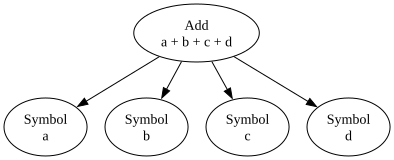

'case1_pure_addition_a.pdf'

In [4]:
case1_a_expr = a+b+c+d
case1_a = setg(case1_a_expr)
display(case1_a)
case1_a.render('case1_pure_addition_a')

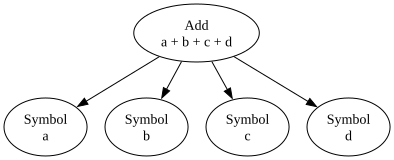

'case1_pure_addition_b.pdf'

In [5]:
case1_b_expr = d+b+a+c
case1_b = setg(case1_b_expr)
display(case1_b)
case1_b.render('case1_pure_addition_b')

In [6]:
case1_a_expr == case1_b_expr

True

# Case 2 - Pure Multiplication

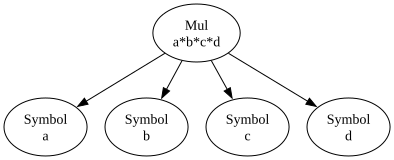

'case2_pure_multiplication_a.pdf'

In [7]:
case2_a_expr = a*b*c*d
case2_a = setg(case2_a_expr)
display(case2_a)
case2_a.render('case2_pure_multiplication_a')

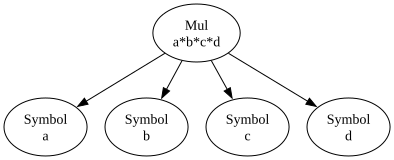

'case2_pure_multiplication_b.pdf'

In [9]:
case2_b_expr = d*c*a*b
case2_b = setg(case2_b_expr)
display(case2_b)
case2_b.render('case2_pure_multiplication_b')

In [10]:
case2_a_expr == case2_b_expr

True

# Case 3 - Square of a Pure Expression

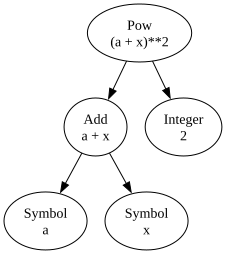

'case3_square_positive_a.pdf.pdf'

In [11]:
case3_a_expr = (x+a)**2
case3_a = setg(case3_a_expr)
display(case3_a)
case3_a.render('case3_square_positive_a.pdf')

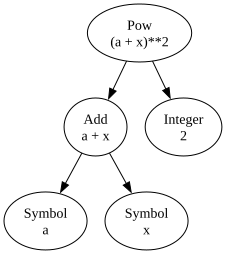

'case3_square_positive_b.pdf.pdf'

In [13]:
case3_b_expr = (a+x)**2
case3_b = setg(case3_b_expr)
display(case3_b)
case3_b.render('case3_square_positive_b.pdf')

# Case 4 Mixed Addition

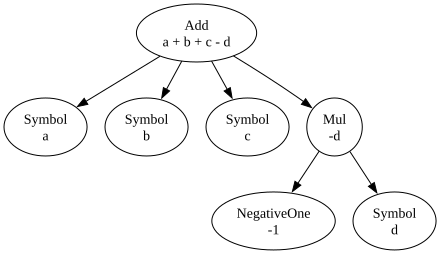

'case4_mixed_addition_a.pdf'

In [14]:
case_4a_expr = a + b + c - d
case_4a = setg(case_4a_expr)
display(case_4a)
case_4a.render('case4_mixed_addition_a')

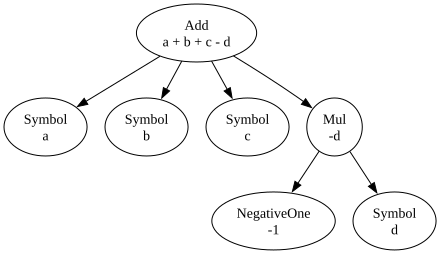

'case4_mixed_addition_b.pdf'

In [15]:
case_4b_expr = -d + b + a + c
case_4b = setg(case_4b_expr)
display(case_4b)
case_4b.render('case4_mixed_addition_b')

In [16]:
case_4a_expr == case_4b_expr

True

# Case 5 - Mixed Multiplication

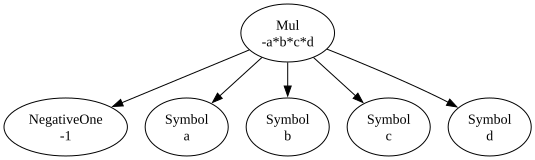

'case5_mixed_multiplication_a.pdf'

In [17]:
case5_a_expr = (-a)*b*c*d
case5_a = setg((-a)*b*c*d)
display(case5_a)
case5_a.render('case5_mixed_multiplication_a')

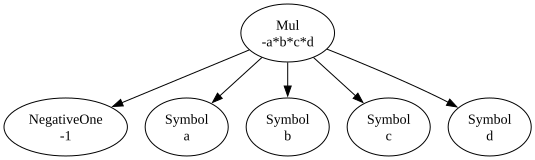

'case5_mixed_multiplication_b.pdf'

In [29]:
case5_b_expr = b*a*c*(-d)
case5_b = setg(case5_b_expr)
display(case5_b)
case5_b.render('case5_mixed_multiplication_b')

In [22]:
case5_a_expr == case5_b_expr 

True

# Case 6 - Square of a Mixed Expression

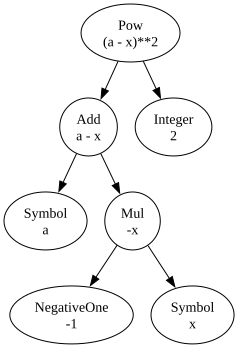

'case6_square_mixed_expr_a.pdf'

In [23]:
case6_a_expr = (a-x)**2
case6_a = setg( case6_a_expr )
display(case6_a)
case6_a.render('case6_square_mixed_expr_a')

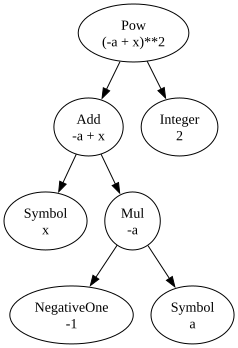

'case6_square_mixed_expr_b.pdf'

In [24]:
case6_b_expr = (x-a)**2
case6_b = setg( case6_b_expr )
display(case6_b)
case6_b.render('case6_square_mixed_expr_b')

In [25]:
case6_a_expr == case6_b_expr

False

In [26]:
sym.simplify( case6_a_expr - case6_b_expr )

0